In [18]:
import pandas as pd
import networkx as nx

files = {
    "MAOL": r"C:\Users\vachi\Downloads\maol_1.1_edge_list.csv",
    "FAFB": r"C:\Users\vachi\Downloads\fafb_783_edge_list.csv",
    "BANC": r"C:\Users\vachi\Downloads\banc_626_edge_list (1).csv"
}

graphs = {}

for name, path in files.items():
    df = pd.read_csv(path)
    df.columns = ["source", "target"]
    graphs[name] = nx.from_pandas_edgelist(df, "source", "target", create_using=nx.DiGraph())

print("loaded")

loaded


In [ ]:
def signature(G, n):
    if n not in G:
        return None

    out_n = len(list(G.successors(n)))
    in_n = len(list(G.predecessors(n)))

    # second-order flow context (VERY IMPORTANT)
    out2 = 0
    for v in list(G.successors(n))[:10]:
        out2 += len(list(G.successors(v)))

    return (out_n, in_n, out2)

In [19]:
from collections import defaultdict

sig_maps = {}

for name, G in graphs.items():
    mp = defaultdict(list)

    for n in G.nodes():
        s = signature(G, n)
        if s:
            mp[s].append(n)

    sig_maps[name] = mp

print("signature maps built")

signature maps built


In [20]:
shared_sigs = set(sig_maps["MAOL"]) & set(sig_maps["FAFB"]) & set(sig_maps["BANC"])

print("shared structural roles:", len(shared_sigs))

shared structural roles: 90


In [21]:
MAOL_nodes, FAFB_nodes, BANC_nodes = [], [], []

for s in list(shared_sigs)[:2000]:   # allow scale
    MAOL_nodes += sig_maps["MAOL"][s]
    FAFB_nodes += sig_maps["FAFB"][s]
    BANC_nodes += sig_maps["BANC"][s]

print(len(MAOL_nodes), len(FAFB_nodes), len(BANC_nodes))

647 2052 4930


In [22]:
N = min(len(MAOL_nodes), len(FAFB_nodes), len(BANC_nodes))

df = pd.DataFrame({
    "MAOL": MAOL_nodes[:N],
    "FAFB": FAFB_nodes[:N],
    "BANC": BANC_nodes[:N],
})

df.to_csv("network.csv", index=False)

print("saved network.csv with rows:", N)
df.head()

saved network.csv with rows: 647


,MAOL,FAFB,BANC
0,37865,720575940609719250,720575941513210371
1,18540,720575940618594117,720575941440141909
2,45678,720575940625144061,720575941553640676
3,23372,720575940612836245,720575941429726857
4,17300,720575940614969651,720575941451317575


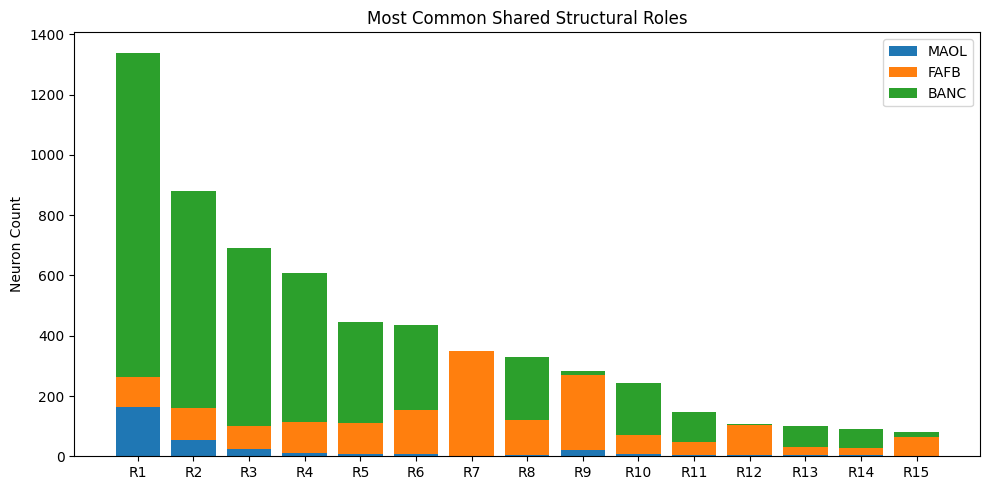

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []

for sig in shared_sigs:
    rows.append({
        "signature": str(sig),
        "MAOL": len(sig_maps["MAOL"][sig]),
        "FAFB": len(sig_maps["FAFB"][sig]),
        "BANC": len(sig_maps["BANC"][sig])
    })

role_df = pd.DataFrame(rows)

role_df["total"] = (
    role_df["MAOL"] +
    role_df["FAFB"] +
    role_df["BANC"]
)

role_df = role_df.sort_values("total", ascending=False).head(15)

plt.figure(figsize=(10,5))

x = range(len(role_df))

plt.bar(x, role_df["MAOL"], label="MAOL")
plt.bar(x, role_df["FAFB"], bottom=role_df["MAOL"], label="FAFB")
plt.bar(
    x,
    role_df["BANC"],
    bottom=role_df["MAOL"] + role_df["FAFB"],
    label="BANC"
)

plt.xticks(x, [f"R{i+1}" for i in x])
plt.ylabel("Neuron Count")
plt.title("Most Common Shared Structural Roles")
plt.legend()

plt.tight_layout()
plt.savefig("shared_roles.png", dpi=300)
plt.show()

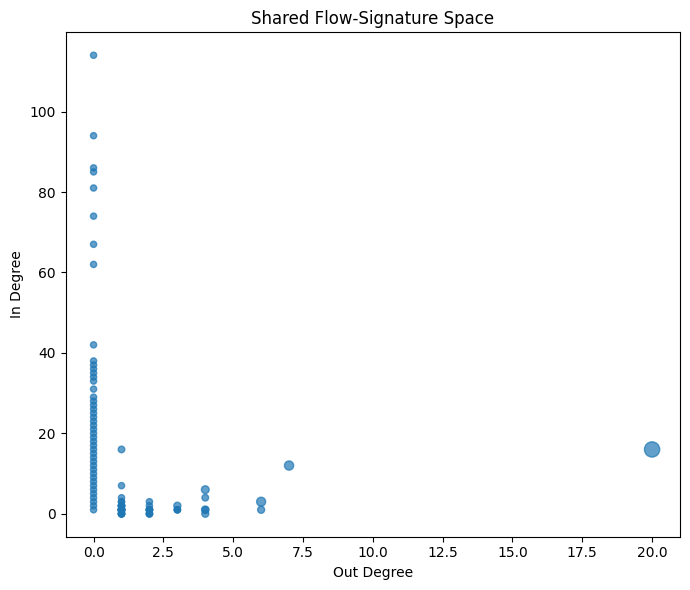

In [41]:
import matplotlib.pyplot as plt

sample = []

for sig in shared_sigs:
    sample.append(sig)

sample = sample[:200]

out_deg = [s[0] for s in sample]
in_deg = [s[1] for s in sample]
out2 = [s[2] for s in sample]

plt.figure(figsize=(7,6))

sc = plt.scatter(
    out_deg,
    in_deg,
    s=[o/10 + 20 for o in out2],
    alpha=0.7
)

plt.xlabel("Out Degree")
plt.ylabel("In Degree")
plt.title("Shared Flow-Signature Space")

plt.tight_layout()
plt.savefig("flow_signature_space.png", dpi=300)
plt.show()

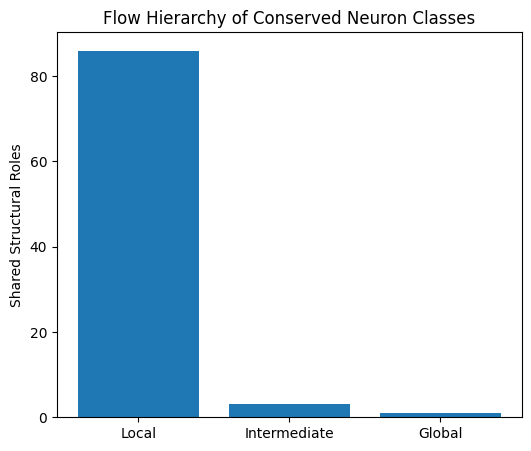

In [42]:
import matplotlib.pyplot as plt

shared = list(shared_sigs)

low = sum(1 for s in shared if s[2] < 100)
mid = sum(1 for s in shared if 100 <= s[2] < 1000)
high = sum(1 for s in shared if s[2] >= 1000)

plt.figure(figsize=(6,5))

plt.bar(
    ["Local","Intermediate","Global"],
    [low, mid, high]
)

plt.ylabel("Shared Structural Roles")
plt.title("Flow Hierarchy of Conserved Neuron Classes")

plt.savefig("flow_hierarchy.png", dpi=300)
plt.show()

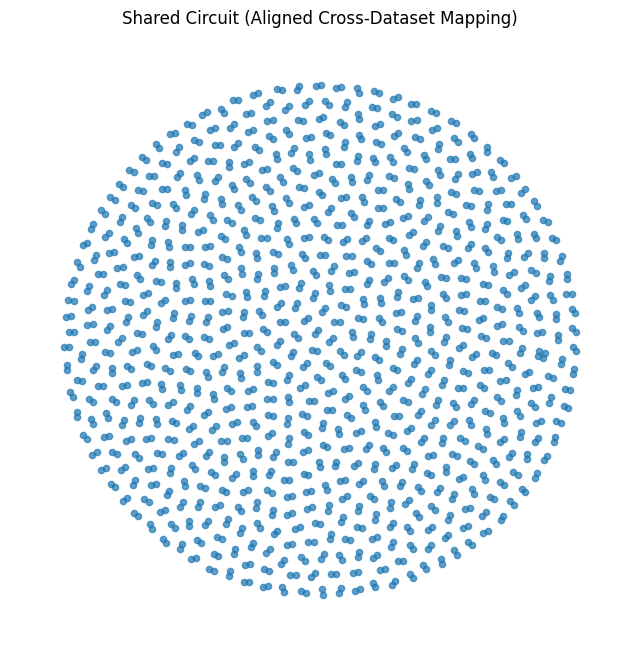

In [29]:
df = pd.read_csv("network.csv")
plot_circuit(df)

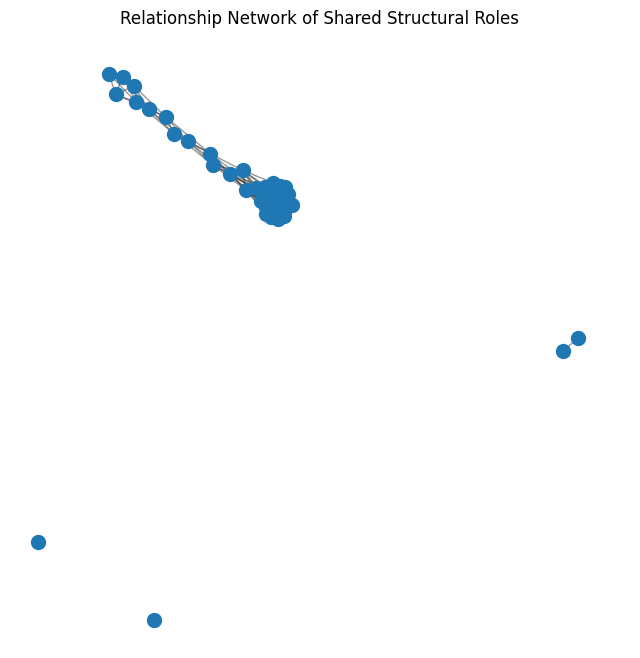

In [49]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

shared_list = list(shared_sigs)[:40]

for sig in shared_list:
    G.add_node(sig)

for i in range(len(shared_list)):
    for j in range(i+1, len(shared_list)):

        s1 = shared_list[i]
        s2 = shared_list[j]

        dist = (
            abs(s1[0]-s2[0]) +
            abs(s1[1]-s2[1])
        )

        if dist < 10:
            G.add_edge(s1, s2)

plt.figure(figsize=(8,8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=100)
nx.draw_networkx_edges(G, pos, alpha=0.4)

plt.title("Relationship Network of Shared Structural Roles")

plt.axis("off")

plt.savefig("role_network.png", dpi=300)
plt.show()

In [50]:
network = pd.read_csv("network.csv")

sample = network.sample(20, random_state=42)

sample

,MAOL,FAFB,BANC
634,38644,720575940615726954,720575941632957344
220,14463,720575940618300628,720575941475586334
426,25422,720575940615610218,720575941533298307
428,31821,720575940626862108,720575941506494012
72,21886,720575940642256373,720575941633456315
437,26305,720575940629498267,720575941599193129
181,32787,720575940632032587,720575941520213171
131,41488,720575940630445635,720575941447466772
231,34866,720575940620906516,720575941456461296
277,41342,720575940633003148,720575941613376988
